# Week 3 Assignment - Classification

In [1]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 366.1 kB/s eta 0:04:37
   ---------------------------------------- 0.8/101.7 MB 564.9 kB/s eta 0:02:59
   ---------------------------------------- 1.0/101.7 MB 639.4 kB/s eta 0:02:38
   ---------------------------------------- 1.0/101.7 MB 639.4 kB/s eta 0:02:38
    --------------------------------------

In [24]:
# importing libraries  
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

In [25]:
import os

In [26]:
# Loadios Dataset
df = pd.read_csv(r"C:\Users\HP\Downloads\Country-data.csv")

print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [28]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [29]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

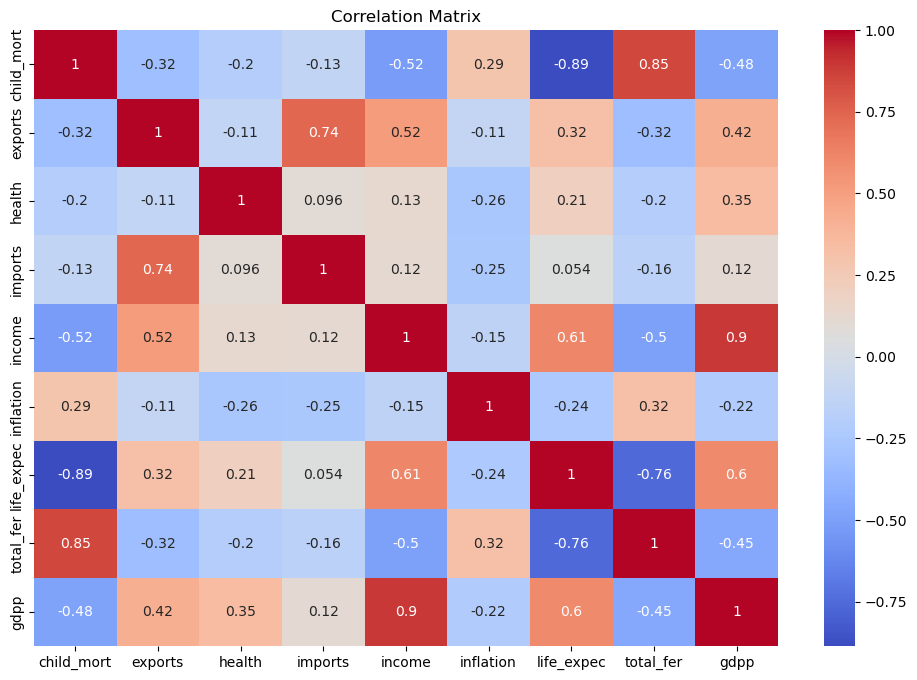

In [30]:
#let's see which features move together and which ones don't by checking correlation btw different columns
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("country", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Feature Distribution Analysis->
Understanding the distribution of each feature is essential before applying machine learning algorithms.

Using histograms and density plots, we can identify:

- Skewed distributions
- Normal distributions
- Extreme values
- Potential outliers

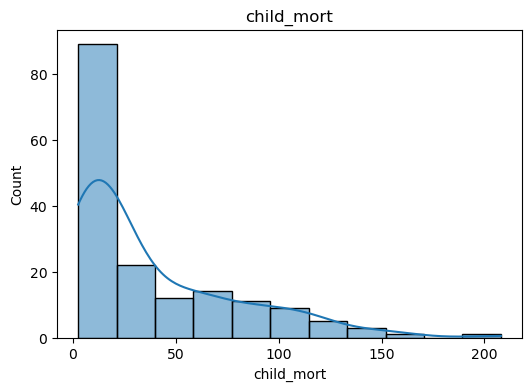

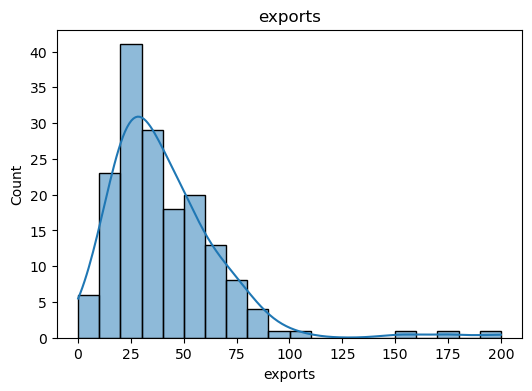

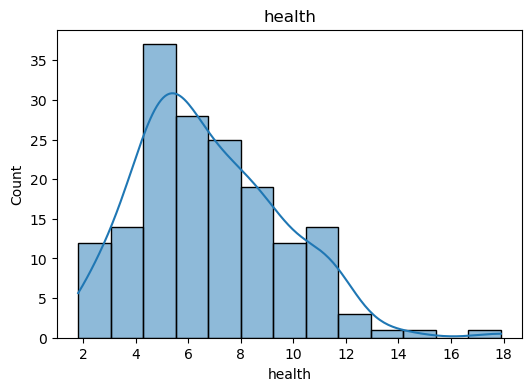

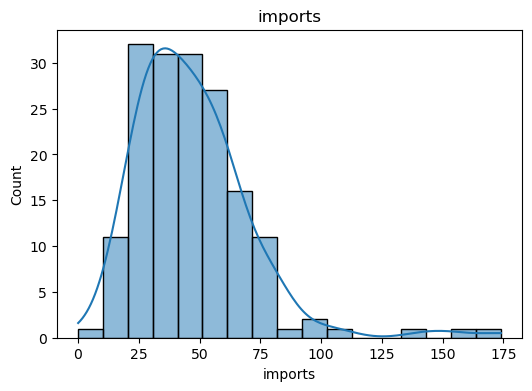

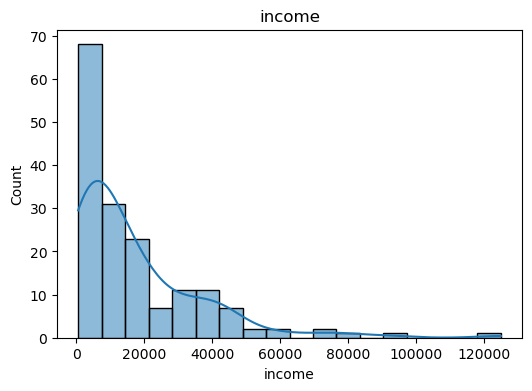

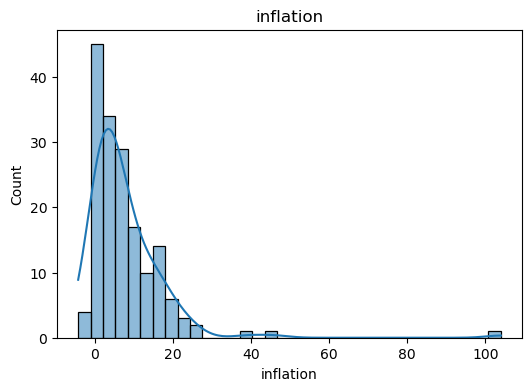

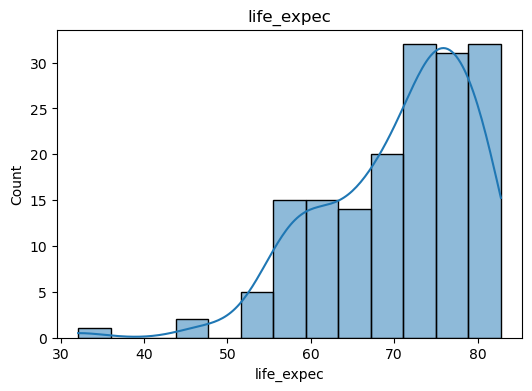

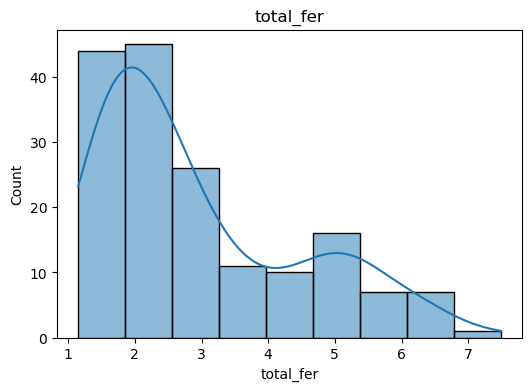

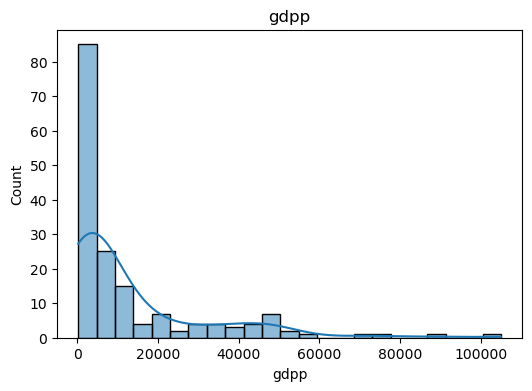

In [31]:
num_cols = df.columns[1:]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Outlier Detection

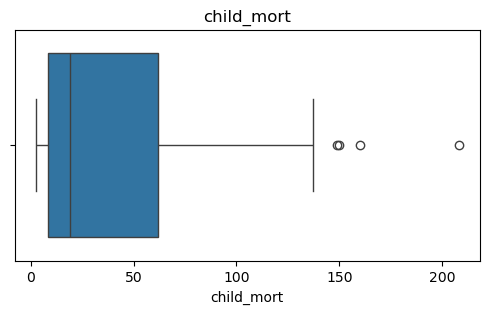

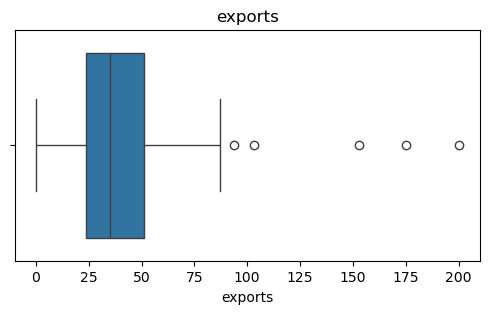

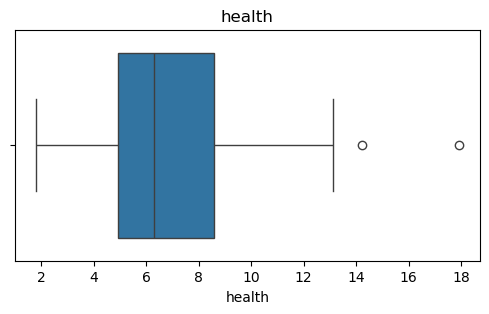

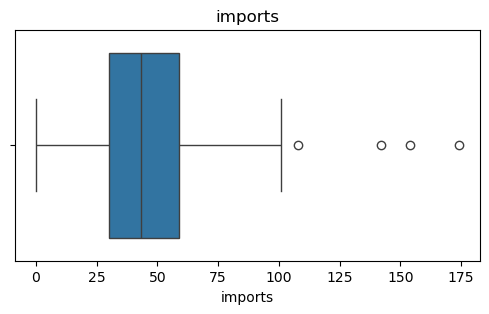

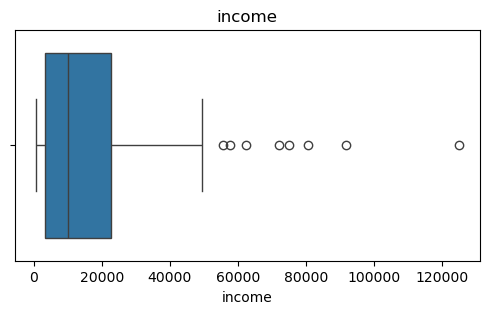

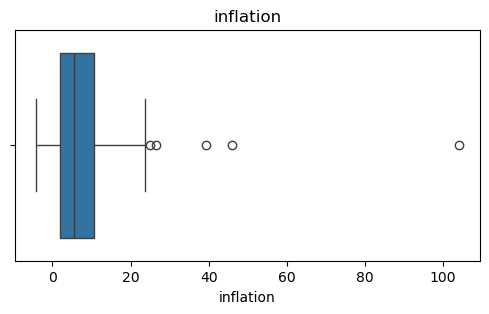

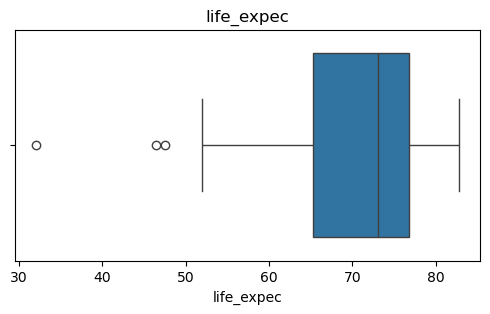

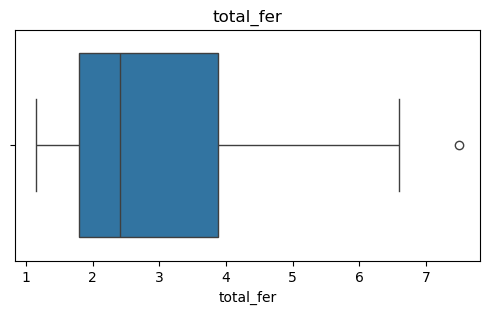

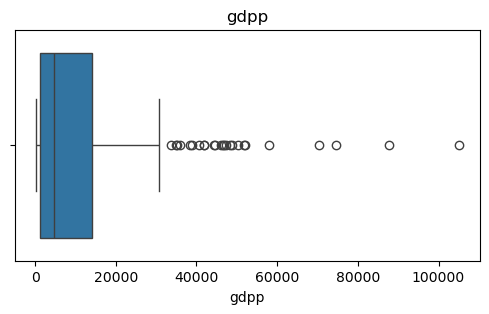

In [32]:
# Using box plot 
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Feature Scaling

In [33]:
X = df.drop("country", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


Determing cluster optimally by elbow method using wcss

In [35]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

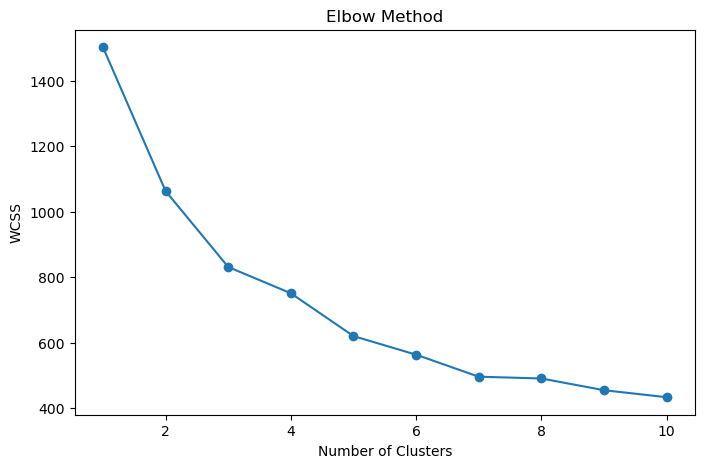

In [36]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# K-Means Clustering

Taking k = 3 as number of clusters formed

In [38]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [39]:
df["Cluster"].value_counts()

Cluster
0    86
2    45
1    36
Name: count, dtype: int64

In [40]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


# Dimensionality reduction using PCA

In [41]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [42]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

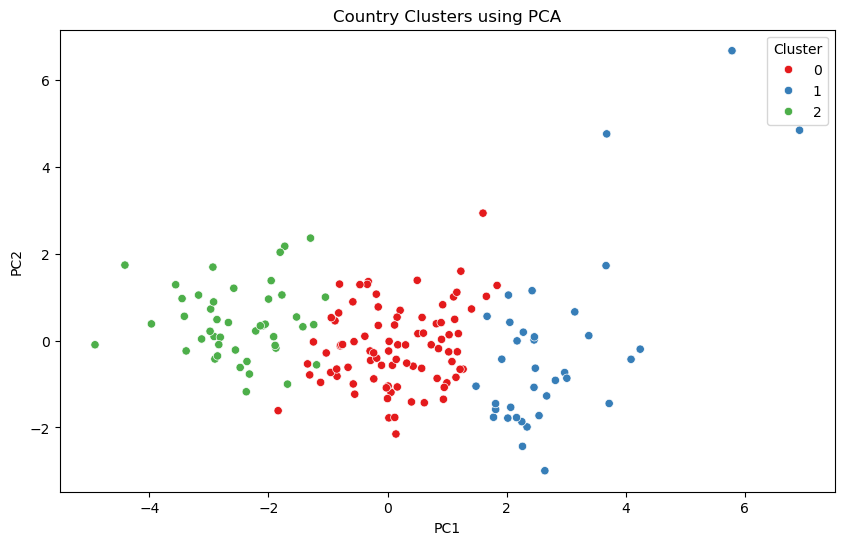

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set1"
)

plt.title("Country Clusters using PCA")

plt.show()

Visualizing Countires cluster

# Using DBSCAN clustering

Unlike K-Means, DBSCAN does not require a predefined number of clusters , It identifies Dense regions of similar observations like Noise points and  Outliers

In [45]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

In [48]:
# The countries that have values as -1 are referred as outliers
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

In [49]:
outliers = df[df["DBSCAN_Cluster"] == -1]

outliers[["country"]]

,country
3,Angola
23,Brunei
31,Central African Republic
37,"Congo, Dem. Rep."
38,"Congo, Rep."
49,Equatorial Guinea
55,Gabon
66,Haiti
72,Iraq
73,Ireland


Countries identified as noise points by DBSCAN may have significantly different characteristics compared to the rest of the dataset

In [51]:
X = df.drop(
    ["country", "Cluster", "DBSCAN_Cluster"],
    axis=1
)

y = df["Cluster"]

# Data Classification

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Implementing Random Forest

In [53]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [54]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)


Accuracy: 0.9705882352941176


In [56]:
print(classification_report(y_test,rf_pred ))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



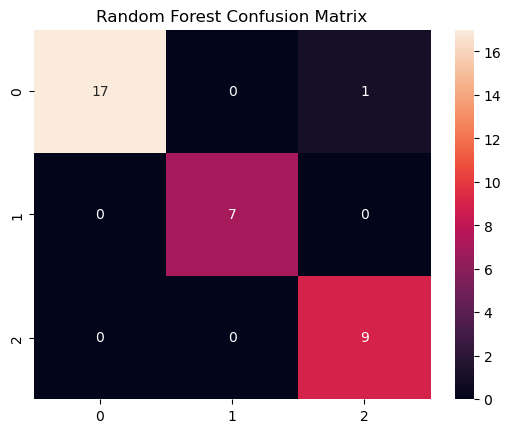

In [57]:
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# Implementing XGBoost classifier

In [58]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


In [60]:
print("Accuracy:",accuracy_score(y_test, xgb_pred))

Accuracy: 0.9705882352941176


In [61]:
print(classification_report(y_test,xgb_pred ))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



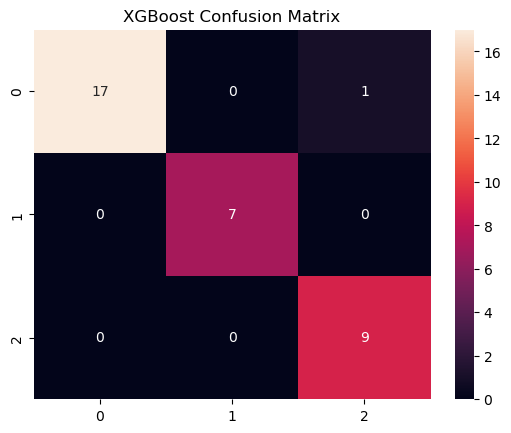

In [62]:
sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

# Model evaluation 

In [63]:
rf_acc = accuracy_score(y_test, rf_pred)

xgb_acc = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest","XGBoost"],
    "Accuracy": [rf_acc, xgb_acc]
})

comparison

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,0.970588


# Feature Importance analysis 

In [64]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.296120
8,gdpp,0.227301
4,income,0.164629
6,life_expec,0.164469
7,total_fer,0.097647
2,health,0.017380
1,exports,0.011820
5,inflation,0.011761
3,imports,0.008873


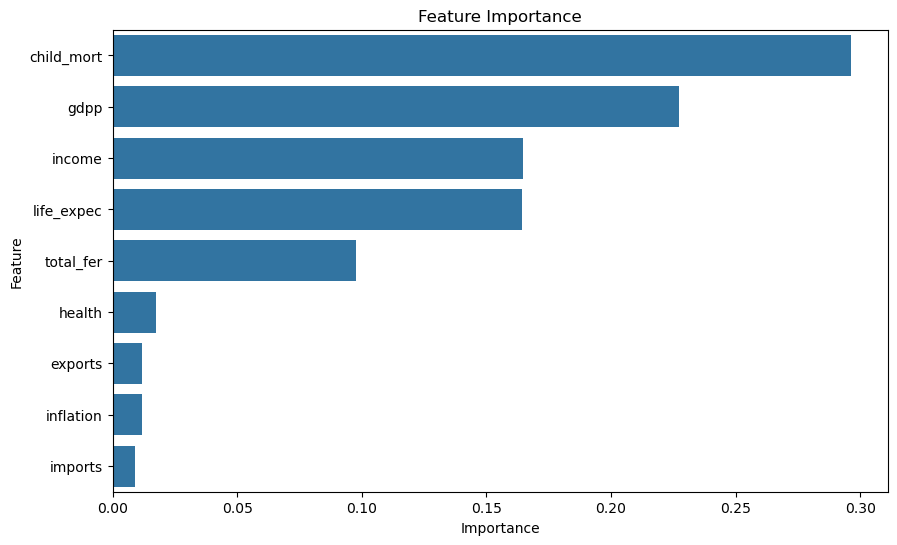

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

Visual Representation

In [66]:
df[df["Cluster"] == 2][
    ["country","income","gdpp","child_mort"]
].head(20)

,country,income,gdpp,child_mort
0,Afghanistan,1610,553,90.2
3,Angola,5900,3530,119.0
17,Benin,1820,758,111.0
25,Burkina Faso,1430,575,116.0
26,Burundi,764,231,93.6
28,Cameroon,2660,1310,108.0
31,Central African Republic,888,446,149.0
32,Chad,1930,897,150.0
36,Comoros,1410,769,88.2
37,"Congo, Dem. Rep.",609,334,116.0


## Conclusion

started with country data, cleaned it up and explored the features.

scaled everything, found the right k using elbow method, then ran K-Means 
and DBSCAN for clustering. used PCA to visualize the clusters in 2D.

profiled the clusters — one group developed, one developing, one underdeveloped.

on top of that trained Random Forest and XGBoost to classify countries into 
these clusters. Both came out the same.

child_mort, gdpp and income turned out to be the most important features overall.